In [2]:
from ray.tune.analysis     import ExperimentAnalysis
# from   ray.tune.schedulers import ASHAScheduler
# import ray.cloudpickle     as pickle
# from   ray import tune
# from   ray import train
# from ray.train import Checkpoint, get_checkpoint
from train import GenerateModel, federate_model
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from metrics import eval_model, compare_metric
from functools import partial
from tqdm import tqdm
import json
import torch
import os
import pandas as pd
import datetime

working_dir  = "/home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS" 

columns = [
    "auc_macro",
    "auc_micro",
    "f1_macro",
    "f1_micro",
    "time_since_restore",
    "config/lr",
    "config/n_filters",
    "config/window_size",
    "config/epochs",
    "config/batch_size"
]
benchmark = {
    'auc_macro' : 0.884,
    'auc_micro' : 0.916,
    'f1_macro'  : 0.576,
    'f1_micro'  : 0.633
}

In [3]:
tune_results = os.path.join(working_dir,"S3_Bucket", "results")
print(tune_results)
folders = os.listdir(tune_results)
folders.sort()
print(folders)
folder_path = os.path.join(tune_results,folders[1])
print(folder_path)
trials = ExperimentAnalysis(os.path.join(folder_path))

"""

auc_macro	auc_micro	f1_macro	f1_micro	time_since_restore	config/lr	config/n_filters	config/window_size	config/epochs	config/batch_size
3	0.908658	0.932497	0.339975	0.318783	4651.724663	0.000153	21	6	2	32
2	0.908795	0.931912	0.531100	0.533903	6424.957231	0.000365	16	3	4	16
"""

2025-10-09 16:08:07,687	WARNING experiment_analysis.py:180 -- Failed to fetch metrics for 46 trial(s):
- train_model_c310a_00024: FileNotFoundError('Could not fetch metrics for train_model_c310a_00024: both result.json and progress.csv were not found at /home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS/S3_Bucket/results/train_model_2025-10-06_17-49-09/train_model_c310a_00024_24_batch_size=16,epochs=4,lr=0.0018,n_filters=13,window_size=7_2025-10-06_17-49-10')
- train_model_c310a_00026: FileNotFoundError('Could not fetch metrics for train_model_c310a_00026: both result.json and progress.csv were not found at /home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS/S3_Bucket/results/train_model_2025-10-06_17-49-09/train_model_c310a_00026_26_batch_size=16,epochs=4,lr=0.0051,n_filters=16,window_size=5_2025-10-06_17-49-10')
- train_model_c310a_00049: FileNotFoundError('Could not fetch metrics for train_model_c310a_00049: both result.json and progress.csv were not found at /home/drew/FL-with-MIM

/home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS/S3_Bucket/results
['train_model_2025-10-04_20-25-00', 'train_model_2025-10-06_17-49-09']
/home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS/S3_Bucket/results/train_model_2025-10-06_17-49-09


'\n\nauc_macro\tauc_micro\tf1_macro\tf1_micro\ttime_since_restore\tconfig/lr\tconfig/n_filters\tconfig/window_size\tconfig/epochs\tconfig/batch_size\n3\t0.908658\t0.932497\t0.339975\t0.318783\t4651.724663\t0.000153\t21\t6\t2\t32\n2\t0.908795\t0.931912\t0.531100\t0.533903\t6424.957231\t0.000365\t16\t3\t4\t16\n'

In [4]:
df: pd.DataFrame = trials.dataframe()
df[columns].sort_values(by = 'f1_macro',ascending=False)

,auc_macro,auc_micro,f1_macro,f1_micro,time_since_restore,config/lr,config/n_filters,config/window_size,config/epochs,config/batch_size
2,0.889369,0.917716,0.291617,0.281874,15787.497869,0.000793,17,5,6,32
0,0.862320,0.898383,0.256770,0.252087,9081.114941,0.000866,6,3,6,32
1,0.876656,0.908324,0.247037,0.240248,3281.186902,0.011034,10,3,2,32


In [5]:
df[columns].sort_values(by = 'auc_macro',ascending=False).head()

,auc_macro,auc_micro,f1_macro,f1_micro,time_since_restore,config/lr,config/n_filters,config/window_size,config/epochs,config/batch_size
3,0.890095,0.917622,0.236063,0.235592,16608.244741,0.003593,19,5,6,32
4,0.879263,0.908322,0.257399,0.254147,10158.032358,0.000112,10,6,4,16
2,0.862676,0.898723,0.267295,0.261484,7658.947246,0.000273,7,7,3,16
0,0.856175,0.888252,0.205023,0.205091,7625.325829,0.023599,11,6,3,16
1,0.846639,0.874297,0.204886,0.204886,11020.293437,0.053736,16,6,4,32


---

In [6]:
working_dir  = "/home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS" 
logging_path = os.path.join(working_dir,"S3_Bucket", "logs","logger.log")
low_ge_path  = os.path.join(working_dir,"S3_Bucket", "logs","low_ge.pt")
max_auc_path = os.path.join(working_dir,"S3_Bucket", "logs","max_auc.pt")
model_path   = os.path.join(working_dir,"S3_Bucket")
history_metrics_path = os.path.join(working_dir,"S3_Bucket", "logs","metric_history.json")
latest_model_path    = os.path.join(working_dir,"S3_Bucket", "logs","latest_model.pt")
os.path.isfile(logging_path)

False

In [6]:
######################################## CONFIG
config = {
        "batch_size" : 32,
        "lr"         : 0.00001,
        "n_filters"  : 21,
        "window_size": 6,
        "epochs"     : 2,
        "rounds"     : 1
    }
######################################## Global Model
model = GenerateModel(table_path   = os.path.join(working_dir,"Model","processed_full.w2v"),
                    num_of_filters = config['n_filters'],
                    kernel_size    = config['window_size'])

model_path = '/home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS/S3_Bucket/logs/latest_model.pt'
state_dict = torch.load(f = model_path,map_location=torch.device("cpu"), weights_only=True)
model.load_state_dict(state_dict)


<All keys matched successfully>

In [7]:
def load_data(type):
    working_dir  = "/home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS" 
    X_val  = torch.load(os.path.join(working_dir,"Data",f"X_{type}.pt"))
    Y_val  = torch.load(os.path.join(working_dir,"Data",f"Y_{type}.pt"))
    return DataLoader(TensorDataset(X_val,Y_val),batch_size=32,shuffle=False)

def log_detail(desc: str, file: str):
    with open(file, mode = 'a') as f:
        time_now = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        f.write(f'{time_now}: {desc}\n')

def save_json(data,filepath): 
    with open(filepath, mode = 'w+') as f:
        json.dump(data,fp = f)

def load_json(filepath):
    with open(filepath, mode = 'r') as f:
        data = json.load(f)
    return data

In [8]:
history_metrics_path = os.path.join(working_dir,"S3_Bucket", "logs","metric_history.json")

20000


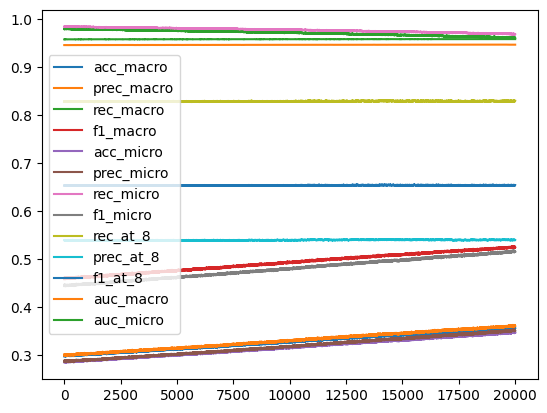

'\n1. 4000 rounds\n2. 5000 rounds\n3. 5000 rounds\n4. 8000 rounds\n5. 5284 rounds\n6. 20_0000 rounds Saved under logs 20_000\n7. 20_0000 rounds Saved under logs 40_000 \ntotal = 67_285 + 20_000\n'

In [9]:
data = load_json(filepath=history_metrics_path)

val, test = zip(*data)
print(len(val))
for key in val[0].keys():
    plt.plot([v[key] for v in val],label = key)
    # plt.plot([v[key] for v in test],label = key)
    
plt.legend()
plt.show()
"""
1. 4000 rounds
2. 5000 rounds
3. 5000 rounds
4. 8000 rounds
5. 5284 rounds
6. 20_0000 rounds Saved under logs 20_000
7. 20_0000 rounds Saved under logs 40_000 
total = 67_285 + 20_000
"""

20000


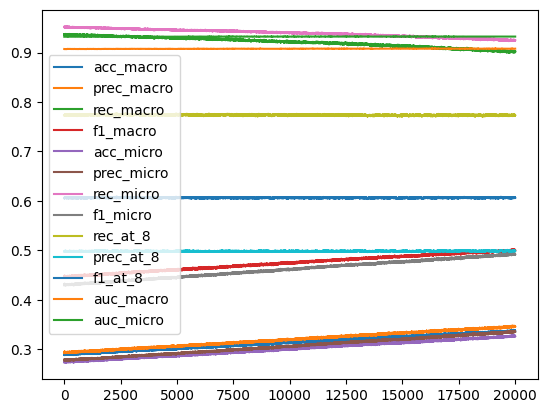

In [10]:
val, test = zip(*data)
print(len(val))
for key in val[0].keys():
    plt.plot([v[key] for v in test],label = key)
    
plt.legend()
plt.show()

In [11]:
model_path = '/home/drew/FL-with-MIMIC/Replicating Mullenbach/AWS/S3_Bucket/logs/latest_model.pt'
state_dict = torch.load(f = model_path,map_location=torch.device("cpu"), weights_only=True)
model.load_state_dict(state_dict)

train_hist = eval_model(model   = model,
           device  = torch.device('cpu'),
           data_loader = load_data("train"))

val_hist   = eval_model(model   = model,
           device  = torch.device('cpu'),
           data_loader = load_data("val"))

test_hist = eval_model(model   = model,
           device  = torch.device('cpu'),
           data_loader = load_data("test"))

benchmark = {
    'auc_macro' : 0.884,
    'auc_micro' : 0.916,
    'f1_macro'  : 0.576,
    'f1_micro'  : 0.633
}
print("Train vs val")

for key in benchmark.keys():
    print(compare_metric(train_hist,val_hist,key))

print("val vs test")

for key in benchmark.keys():
    print(compare_metric(val_hist,test_hist,key))
    
print("Benchmark vs test")
for key in benchmark.keys():
    print(compare_metric(benchmark,test_hist,key))

Train vs val
auc_macro: -4.07% change (0.9464 → 0.9079)
auc_micro: -2.67% change (0.9580 → 0.9324)
f1_macro: -4.73% change (0.5252 → 0.5004)
f1_micro: -4.58% change (0.5158 → 0.4922)
val vs test
auc_macro: -0.10% change (0.9079 → 0.9070)
auc_micro: -0.13% change (0.9324 → 0.9312)
f1_macro: 4.36% change (0.5004 → 0.5222)
f1_micro: 4.11% change (0.4922 → 0.5124)
Benchmark vs test
auc_macro: 2.60% change (0.8840 → 0.9070)
auc_micro: 1.66% change (0.9160 → 0.9312)
f1_macro: -9.34% change (0.5760 → 0.5222)
f1_micro: -19.05% change (0.6330 → 0.5124)
